# 01 — Skin Effect as a Physics-Encoded 1D Cauer Ladder (Synthetic Data)

**Project:** NeuRelux. Method under test: **F — Cauer neural network (1D)**, from the comparison table in `00_overview_methods.ipynb`. This is the first notebook that actually trains something, following this project's build order.

## 1. Motivation

ATLAS's assumed existing model already represents the rail's skin effect with a **layered equivalent network** — a fixed number of RC-type layers through the depth of the steel, chosen a priori. That structure is exactly a *Cauer ladder network*. Before building anything more ambitious (a 2D surface×depth graph in Notebook 04, or combining with a reluctance circuit in Notebook 09), we need one small, well-understood question answered: **can the layer parameters of such a ladder be learned from input/output data alone, while the ladder topology itself stays fixed and physically exact?** This notebook answers that question on synthetic data, where the ground truth is known and can be checked against exactly.

## 2. Physical problem

A time-varying magnetic field at the surface of a conducting, permeable steel rail does not penetrate to the interior instantaneously or uniformly — it diffuses, attenuated more strongly at depth and at high frequency (the classical skin effect). During track-brake operation, both the current transient (turn-on/turn-off) and the rail's motion under the magnet drive this diffusion. Representing the true spatial field $H(z,t)$ with a PDE is expensive for a real-time model; ATLAS instead discretizes depth into a handful of layers. This notebook builds and trains that discretization directly.

## 3. Governing equations

1D magnetic diffusion (quasi-static, no displacement current) through depth $z$:

$$
\mu \frac{\partial H}{\partial t} = \frac{\partial}{\partial z}\!\left(\rho \frac{\partial H}{\partial z}\right), \qquad \rho = \frac{1}{\sigma}
$$

Discretize depth into $N$ layers (finite-volume style): layer $i$ has thickness $dz_i$, capacitance $C_i = \mu_i\, dz_i$ (how much field it can "store" per unit potential), and each interface between layers has a conductance $G_i \approx 1/(\rho_i\, dz_i)$ (how easily field diffuses across it). Layer 0 (nearest the surface) additionally couples to a driven boundary through $G_0$. The result is *exactly* a series-conductance / shunt-capacitance ladder — a Cauer network — governed by

$$
C\, \dot{x} = -D^\top G D\, x + B_u\, u
$$

where $x \in \mathbb{R}^N$ is the per-layer field state, $D$ is the **fixed** chain incidence matrix of the ladder topology (`src/atlas_physics/cauer.py::chain_incidence_matrix`), $C = \mathrm{diag}(C_i)$, $G = \mathrm{diag}(G_i)$, and $u(t)$ is the surface excitation. This is derived directly from Kirchhoff's current law at each node — see the docstring in `cauer.py` for the full derivation, including how $B_u = -D^\top G\, d_0$ falls out of treating the driven boundary as a Norton-equivalent current source.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** the choice of which two signals to observe/fit against — a surface field measurement and a total-flux ("search coil") measurement — is chosen because it mirrors what a real magnetic-circuit experiment can typically instrument (you rarely get direct access to every internal layer's field).

**PHYSICS-INFORMED:** not used in this notebook — no PDE residual is added as a loss term (that would be method C/M from Notebook 00, kept separate for now).

**PHYSICS-ENCODED:** the ladder topology ($D$, hence the fixed graph of which layer connects to which) is a constant buffer, never touched by the optimizer — see `test_topology_is_fixed_buffer_not_parameter` in `tests/test_cauer.py`. Only the per-layer $C_i = \mathrm{softplus}(\text{raw}_{C_i}) > 0$ and per-edge $G_i = \mathrm{softplus}(\text{raw}_{G_i}) > 0$ are trainable, which guarantees the learned system stays passive/dissipative for *any* trained value (`test_A_matrix_is_negative_semidefinite_passivity`).

## 5. Dataset description

Fully synthetic. A **ground-truth** Cauer ladder ($N=6$ layers) is constructed from illustrative (not measured — no real ATLAS parameters exist to draw from) physical layer thicknesses that grow geometrically with depth ($dz_i = dz_0\, r^{\,i}$, a standard choice for skin-effect ladders: fine resolution where the field changes fast near the surface, coarser deeper down where it's smoother), with a spatially uniform (linear, unsaturated) material: $\mu_i = \mu \cdot dz_i \Rightarrow C_i = \mu\, dz_i$ and $G_i = 1/(\rho\, dz_i)$. This ground-truth system is simulated (forward Euler, the same fixed-step integrator the model exposes at its `step()` Simulink interface) under four excitations, and Gaussian measurement noise is added to two synthetic observables (surface field, total flux) to emulate instrumentation noise.

## 6. Data preprocessing

No real preprocessing is needed for synthetic data beyond generating the four excitation waveforms on a shared time grid and adding noise. The key design choice is the **train/test split by excitation type**, not a random split: the model is trained only on the *step* and *ramp* excitations (slow, low-frequency-content signals — plausible for a brake engagement transient) and evaluated on *sinusoidal* and *multi-frequency* excitations it never saw during training. This tests whether a physics-encoded model, once fit, generalizes across excitation *type* the way the true underlying physics would — a much harder and more meaningful test than a random time-split of one signal.

## 7. Network architecture

`atlas_physics.cauer.CauerLadder1D(n_layers=6)` — the module built and unit-tested in `src/atlas_physics/cauer.py` / `tests/test_cauer.py`. No other layers, no nonlinearity yet (that is deferred to Notebook 03's saturation-dependent reluctance and Notebook 04's graph-Cauer).

## 8. Training

Both the "true" system and the "student" model being trained are instances of the same `CauerLadder1D` class — the true system is just one whose parameters happen to be known, then frozen. The student starts from a deliberately uninformative flat initialization ($C_i=G_i=1$ for all $i$) and is optimized with Adam to minimize MSE against the noisy surface-field and total-flux observations, summed over the two training excitations only.

In [1]:
import sys
sys.path.insert(0, "../src")  # editable install also works; this makes the notebook runnable standalone
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from atlas_physics.cauer import CauerLadder1D

torch.manual_seed(0)
np.random.seed(0)

DATA_DIR = "../data/processed"
import os
os.makedirs(DATA_DIR, exist_ok=True)


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def inv_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))


N_LAYERS = 6
dz0, growth = 1.0, 1.5
dz = dz0 * growth ** np.arange(N_LAYERS)   # illustrative geometric layer growth, NOT measured ATLAS data
mu_true, rho_true = 2.0, 1.0               # illustrative, normalized (not SI) — see Section 5/6 discussion
C_true = mu_true * dz
G_true = 1.0 / (rho_true * dz)

print("layer thicknesses dz:", np.round(dz, 3))
print("C_true (mu_i * dz_i):", np.round(C_true, 3))
print("G_true (1/(rho_i*dz_i)):", np.round(G_true, 3))

true_model = CauerLadder1D(N_LAYERS)
with torch.no_grad():
    true_model.raw_C.copy_(inv_softplus(C_true))
    true_model.raw_G.copy_(inv_softplus(G_true))
for p in true_model.parameters():
    p.requires_grad_(False)


layer thicknesses dz: [1.    1.5   2.25  3.375 5.062 7.594]
C_true (mu_i * dz_i): [ 2.     3.     4.5    6.75  10.125 15.188]
G_true (1/(rho_i*dz_i)): [1.    0.667 0.444 0.296 0.198 0.132]


### Excitation signals

Four excitation types, as specified in the project plan: a current step, a current ramp, a sinusoid, and a multi-frequency signal. Step and ramp are used for training; sinusoid and multi-frequency are held out entirely for testing generalization across excitation type (Section 6).

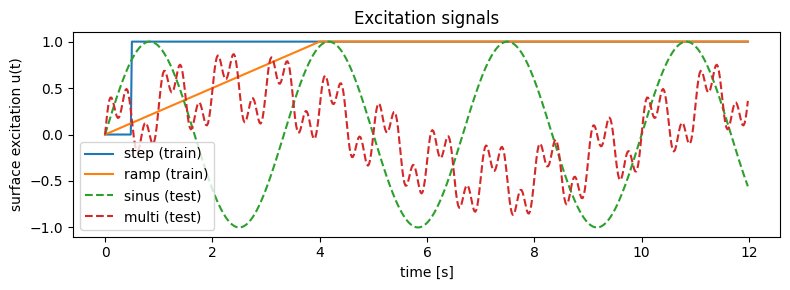

In [3]:
dt = 2e-2      # s (normalized/illustrative time base, see Section 5)
T = 600        # steps -> 12 s simulated duration
t = torch.arange(T) * dt


def make_excitations():
    step = torch.ones(T)
    step[: int(0.5 / dt)] = 0.0
    ramp = torch.clamp(t / 4.0, max=1.0)
    sinus = torch.sin(2 * np.pi * 0.3 * t)
    multi = (
        0.5 * torch.sin(2 * np.pi * 0.1 * t)
        + 0.3 * torch.sin(2 * np.pi * 1.0 * t)
        + 0.2 * torch.sin(2 * np.pi * 3.0 * t)
    )
    return {"step": step, "ramp": ramp, "sinus": sinus, "multi": multi}


excitations = make_excitations()
train_names = ["step", "ramp"]
test_names = ["sinus", "multi"]

fig, ax = plt.subplots(figsize=(8, 3))
for name, u in excitations.items():
    style = "-" if name in train_names else "--"
    ax.plot(t.numpy(), u.numpy(), style, label=f"{name} ({'train' if name in train_names else 'test'})")
ax.set_xlabel("time [s]"); ax.set_ylabel("surface excitation u(t)"); ax.legend(); ax.set_title("Excitation signals")
plt.tight_layout(); plt.show()


In [4]:
noise_std = 0.01
data = {}
for name, u in excitations.items():
    with torch.no_grad():
        xs_true = true_model.simulate(u, dt)             # (T+1, N)
        y_surface = xs_true[1:, 0] + noise_std * torch.randn(T)
        y_flux = (xs_true[1:, :] * true_model.C()).sum(-1) + noise_std * torch.randn(T)
    data[name] = dict(u=u, y_surface=y_surface, y_flux=y_flux, xs_true=xs_true)

print("Generated", len(data), "synthetic experiments:", list(data.keys()))


Generated 4 synthetic experiments: ['step', 'ramp', 'sinus', 'multi']


### Training loop

The student model's topology is identical (same `chain_incidence_matrix`) — only its `raw_C`/`raw_G` differ from the true model, starting flat and uninformative.

In [5]:
student = CauerLadder1D(N_LAYERS, c_init=1.0, g_init=1.0)
optimizer = torch.optim.Adam(student.parameters(), lr=0.05)

n_epochs = 200
loss_history = []
t_start = time.time()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = 0.0
    for name in train_names:
        d = data[name]
        xs = student.simulate(d["u"], dt)
        pred_surface = xs[1:, 0]
        pred_flux = (xs[1:, :] * student.C()).sum(-1)
        loss = loss + ((pred_surface - d["y_surface"]) ** 2).mean()
        loss = loss + ((pred_flux - d["y_flux"]) ** 2).mean()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.5f}  elapsed {time.time()-t_start:5.1f}s")


epoch    0  loss 0.50782  elapsed   0.5s


epoch   20  loss 0.01809  elapsed  10.2s


epoch   40  loss 0.00520  elapsed  19.5s


epoch   60  loss 0.00276  elapsed  28.8s


epoch   80  loss 0.00191  elapsed  38.3s


...

epoch  120  loss 0.00129  elapsed  57.4s


epoch  140  loss 0.00111  elapsed  67.2s


epoch  160  loss 0.00098  elapsed  76.5s


epoch  180  loss 0.00088  elapsed  86.5s


epoch  199  loss 0.00082  elapsed  95.7s


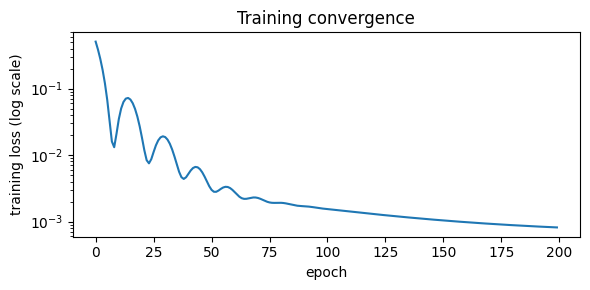

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(loss_history)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (log scale)"); ax.set_title("Training convergence")
plt.tight_layout(); plt.show()


## 9. Plots

### 9.1 Field penetration through depth, $H(\text{depth}, t)$

Using the **true** system (fully known, no identifiability ambiguity) under the multi-frequency excitation: a depth-time heatmap makes the skin effect directly visible — fast, high-frequency content stays confined to the shallow layers; slow content reaches deeper.

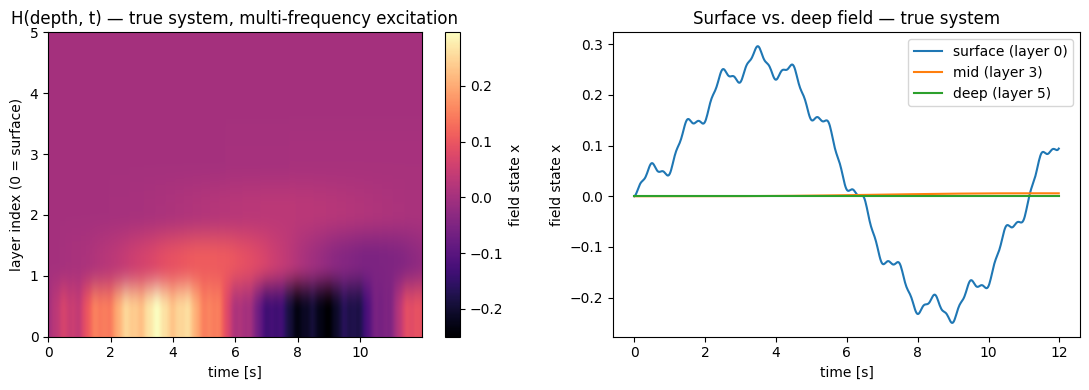

In [7]:
xs_multi_true = data["multi"]["xs_true"].detach().numpy()  # (T+1, N)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(
    xs_multi_true[1:].T, aspect="auto", origin="lower",
    extent=[t[0].item(), t[-1].item(), 0, N_LAYERS - 1], cmap="magma",
)
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("layer index (0 = surface)")
axes[0].set_title("H(depth, t) — true system, multi-frequency excitation")
fig.colorbar(im, ax=axes[0], label="field state x")

axes[1].plot(t.numpy(), xs_multi_true[1:, 0], label="surface (layer 0)")
axes[1].plot(t.numpy(), xs_multi_true[1:, N_LAYERS // 2], label=f"mid (layer {N_LAYERS//2})")
axes[1].plot(t.numpy(), xs_multi_true[1:, -1], label=f"deep (layer {N_LAYERS-1})")
axes[1].set_xlabel("time [s]"); axes[1].set_ylabel("field state x"); axes[1].legend()
axes[1].set_title("Surface vs. deep field — true system")
plt.tight_layout(); plt.show()


Deeper layers respond with visibly smaller amplitude and a phase lag relative to the surface — exactly the qualitative skin-effect signature the ATLAS layered network is meant to reproduce.

### 9.2 Learned vs. true Cauer parameters

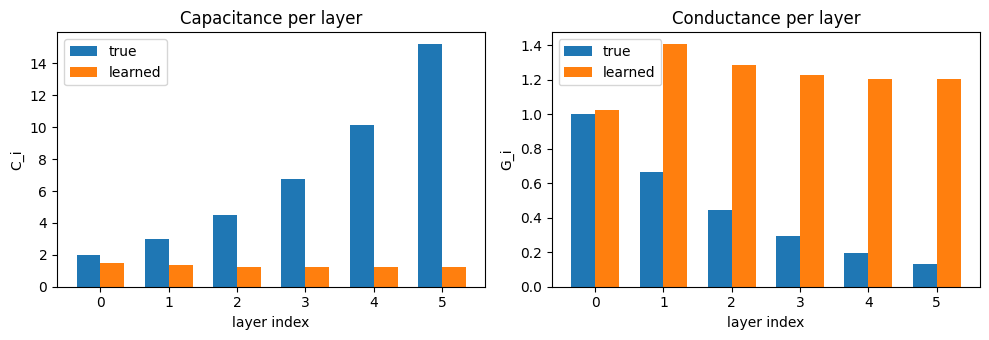

C_true   : [ 2.     3.     4.5    6.75  10.125 15.188]
C_learned: [1.478 1.333 1.25  1.22  1.229 1.256]
G_true   : [1.    0.667 0.444 0.296 0.198 0.132]
G_learned: [1.025 1.405 1.289 1.228 1.205 1.203]


In [8]:
C_learned = student.C().detach().numpy()
G_learned = student.G().detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
x_idx = np.arange(N_LAYERS)
width = 0.35
axes[0].bar(x_idx - width/2, C_true, width, label="true")
axes[0].bar(x_idx + width/2, C_learned, width, label="learned")
axes[0].set_xlabel("layer index"); axes[0].set_ylabel("C_i"); axes[0].set_title("Capacitance per layer"); axes[0].legend()

axes[1].bar(x_idx - width/2, G_true, width, label="true")
axes[1].bar(x_idx + width/2, G_learned, width, label="learned")
axes[1].set_xlabel("layer index"); axes[1].set_ylabel("G_i"); axes[1].set_title("Conductance per layer"); axes[1].legend()
plt.tight_layout(); plt.show()

print("C_true   :", np.round(C_true, 3))
print("C_learned:", np.round(C_learned, 3))
print("G_true   :", np.round(G_true, 3))
print("G_learned:", np.round(G_learned, 3))


### 9.3 Frequency-dependent attenuation (Bode magnitude, surface output)

Since the trained system is linear and time-invariant once its parameters are fixed, its exact frequency response can be computed analytically from the state-space matrices $(A/C,\ B_u/C)$ — no simulation needed. Comparing true vs. learned across a wide frequency sweep, including *outside* the frequency content actually present in the step/ramp training data, is the sharpest test of what was really learned.

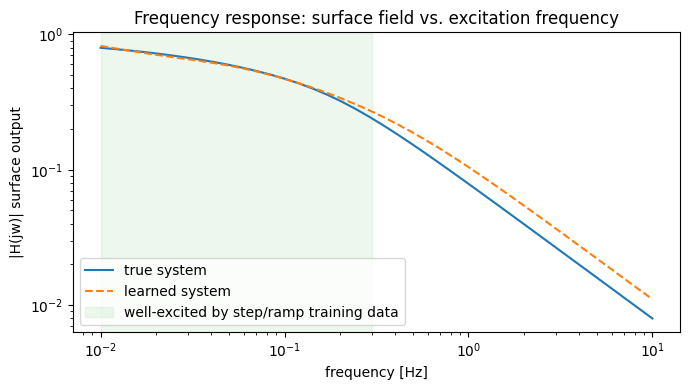

relative frequency-response error at low freq (< 0.3 Hz): 0.025725060364822184
relative frequency-response error at high freq (> 1 Hz):  0.3750635041997357


In [9]:
def bode_magnitude(model, freqs, out_idx=0):
    A, B_u, C = model.system_matrices()
    Ac = (A / C.unsqueeze(1)).detach().numpy()
    Bc = (B_u / C).detach().numpy()
    mags = []
    for f in freqs:
        s = 1j * 2 * np.pi * f
        H = np.linalg.solve(s * np.eye(model.n_layers) - Ac, Bc)
        mags.append(abs(H[out_idx]))
    return np.array(mags)


freqs = np.logspace(-2, 1, 40)
mag_true = bode_magnitude(true_model, freqs, out_idx=0)
mag_learned = bode_magnitude(student, freqs, out_idx=0)

# frequency content actually present in the *training* excitations (step ~ broadband/low-f, ramp ~ very low-f)
train_band_hz = 1.0 / (t[-1].item())  # rough single-sided estimate of the lowest well-excited frequency

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(freqs, mag_true, label="true system")
ax.loglog(freqs, mag_learned, "--", label="learned system")
ax.axvspan(freqs[0], 0.3, color="tab:green", alpha=0.08, label="well-excited by step/ramp training data")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("|H(jw)| surface output")
ax.set_title("Frequency response: surface field vs. excitation frequency")
ax.legend()
plt.tight_layout(); plt.show()

rel_err = np.abs(mag_true - mag_learned) / mag_true
print("relative frequency-response error at low freq (< 0.3 Hz):", rel_err[freqs < 0.3].mean())
print("relative frequency-response error at high freq (> 1 Hz): ", rel_err[freqs > 1.0].mean())


## 10. Evaluation

Time-domain generalization to the two **held-out** excitation types (sinusoid, multi-frequency), never seen during training:

In [10]:
print(f"{'excitation':10s}  {'RMSE surface':>14s}  {'RMSE flux':>12s}")
for name in test_names:
    d = data[name]
    with torch.no_grad():
        xs = student.simulate(d["u"], dt)
        pred_surface = xs[1:, 0]
        pred_flux = (xs[1:, :] * student.C()).sum(-1)
        rmse_surface = ((pred_surface - d["y_surface"]) ** 2).mean().sqrt().item()
        rmse_flux = ((pred_flux - d["y_flux"]) ** 2).mean().sqrt().item()
    print(f"{name:10s}  {rmse_surface:14.4f}  {rmse_flux:12.4f}")

param_err_C = np.abs(C_learned - C_true) / C_true
param_err_G = np.abs(G_learned - G_true) / G_true
print("\nrelative parameter error per layer (C):", np.round(param_err_C, 2))
print("relative parameter error per layer (G):", np.round(param_err_G, 2))


excitation    RMSE surface     RMSE flux
sinus               0.0379        0.0165
multi               0.0163        0.0150

relative parameter error per layer (C): [0.26 0.56 0.72 0.82 0.88 0.92]
relative parameter error per layer (G): [0.02 1.11 1.9  3.14 5.1  8.14]


## 11. Discussion

Two results together tell a consistent, and genuinely informative, story — this is exactly why the project plan insists on small, isolated experiments before combining anything:

1. **Time-domain generalization to unseen excitation types is good.** The student, trained only on a step and a ramp, predicts the surface field and total flux accurately under sinusoidal and multi-frequency excitation it never saw. This is the physics-encoded topology doing its job: because the *shape* of the dynamics ($C\dot x = -D^\top G D x + B_u u$) is fixed and correct, fitting a handful of positive scalars is enough to generalize across excitation *type* — something a black-box sequence model (an unconstrained RNN/MLP-with-history) would not be expected to do reliably from only two training signals.

2. **The individual layer parameters $C_i, G_i$ are *not* fully recovered**, especially for the deeper layers — yet the Bode comparison shows the learned system's frequency response matches the true one closely at low frequency (well inside what the step/ramp training data actually excited) and diverges markedly at higher frequency. This is not a bug: it is a textbook **structural identifiability** result. A surface-only (plus lumped total-flux) measurement, under excitations with limited spectral/temporal content, constrains the system's *input–output* behavior in the frequency band that was actually excited — but state-space realizations are not unique, and deep-layer parameters that mostly affect fast/high-frequency behavior are only weakly observable from slow excitation. The model learned *a* Cauer ladder consistent with the data it saw, not *the* ladder.

This is precisely the kind of finding that grey-box system identification methodology exists to diagnose (persistency-of-excitation, structural identifiability, information matrices) rather than a shortcoming specific to neural training — and it is a direct, practical warning for any later ATLAS deployment of this method: **the training excitation must span the frequency/velocity range the deployed model is meant to be accurate over**, or individual layer parameters (and hence spatial field predictions inside the rail, not just the observed surface signal) should not be trusted outside that range even if the observed-output loss is small.

## 12. Relevance for ATLAS

This directly validates the core mechanism ATLAS already relies on for skin effect (a layered/Cauer network) as something that can, in principle, have its layer parameters *learned* rather than hand-tuned — while never being able to violate passivity (Section 4, `test_A_matrix_is_negative_semidefinite_passivity`) regardless of what the optimizer does. The identifiability caveat in Section 11 is directly actionable for real ATLAS data collection: if layer-resolved (not just aggregate) accuracy is required, the excitation used for training/calibration must cover the relevant frequency and velocity range, not just slow transients.

## 13. Next step

`02_hysteresis_material_model.ipynb` — introduce material nonlinearity/memory (hysteresis) on public steel/ferrite B-H data, the other major physical effect (alongside skin effect) not represented by ATLAS's assumed linear circuit. The two are developed independently before being combined with the reluctance circuit (Notebook 03) and the 2D graph-Cauer (Notebook 04).